In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df['Дата'].dtype)

datetime64[ns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата', as_index=False)['Количество'].sum()

Вывести несколько первых строк сгруппированных данных

In [6]:
print(grouped_df.head(10))

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055
5 2018-01-10        3653
6 2018-01-11        3176
7 2018-01-12        3092
8 2018-01-13        3294
9 2018-01-14        3228


Нарисуйте график продаж у `grouped_df`

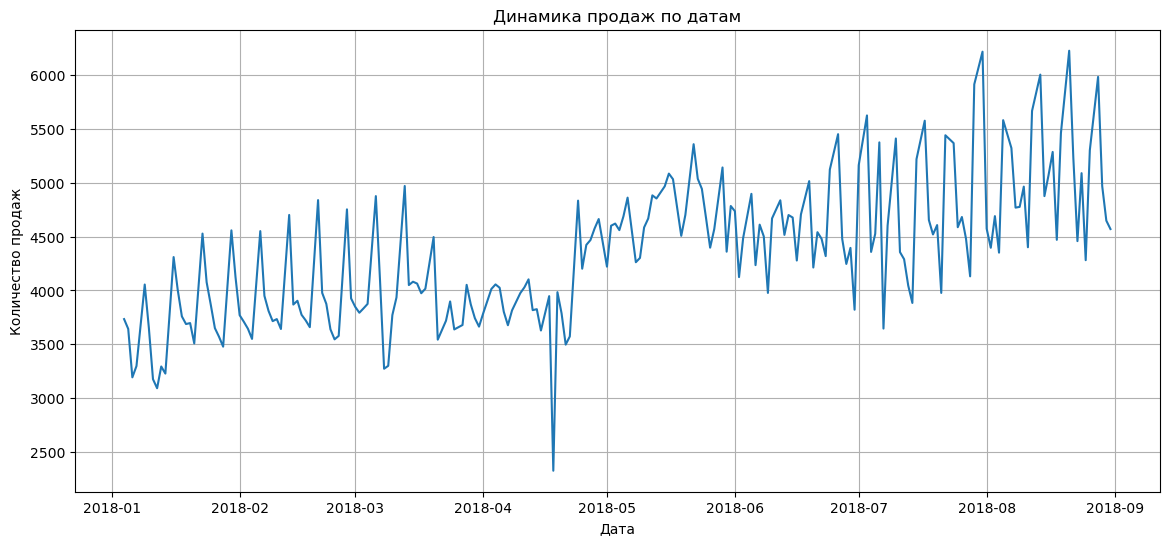

In [7]:
plt.figure(figsize=(14,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Динамика продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [8]:
#на графике выражены сильные колебания, присутствую пики связанные с сезонностью и изменением спрооса в определнные даты. Тренд растущий но а апрель-май видно сильные падение. 

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
weather = pd.read_csv(
    'weather6.csv',
    sep=';',
    encoding='utf-8',
    skiprows=6,
    index_col=False
)
print(weather.columns)

Index(['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10',
       'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch',
       'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', 'E'', 'sss'],
      dtype='object')


In [19]:
weather = weather.iloc[:, [0, 1]]
weather.columns = ['Дата', 'T']
weather['Дата'] = pd.to_datetime(
    weather['Дата'],
    format='%d.%m.%Y %H:%M',
    errors='coerce'
)
weather['T'] = pd.to_numeric(
    weather['T'],
    errors='coerce'
)
weather['Дата'] = weather['Дата'].dt.date
weather.head()

,Дата,T
0,2018-12-31,-18.4
1,2018-12-31,-17.2
2,2018-12-31,-14.8
3,2018-12-31,-11.2
4,2018-12-31,-12.7


In [20]:
#средняя температура за день 

In [21]:
daily_temp = (
    weather.groupby('Дата', as_index=False)['T']
    .mean()
)
daily_temp.head()

,Дата,T
0,2018-01-01,-9.4625
1,2018-01-02,-9.5125
2,2018-01-03,-11.4625
3,2018-01-04,-14.0750
4,2018-01-05,-16.8625


In [22]:
#Объединяем с груп дф 

In [23]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date
merged_df = grouped_df.merge(
    daily_temp,
    on='Дата',
    how='left'
)
merged_df.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


In [24]:
#график продаж и температуры

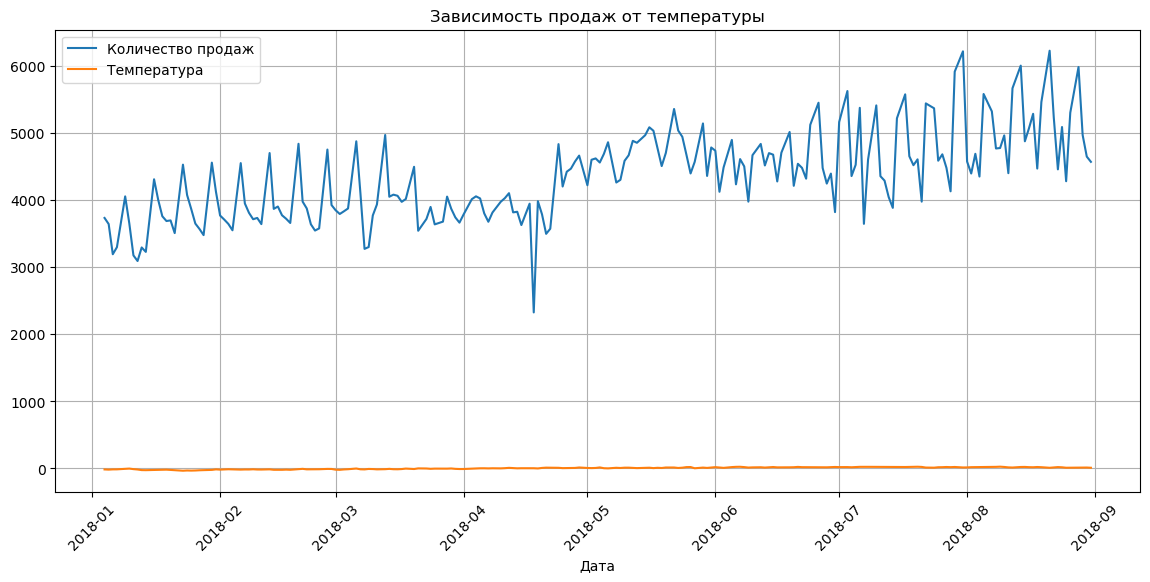

In [26]:
plt.figure(figsize=(14,6))
plt.plot(
    merged_df['Дата'],
    merged_df['Количество'],
    label='Количество продаж'
)
plt.plot(
    merged_df['Дата'],
    merged_df['T'],
    label='Температура'
)
plt.title('Зависимость продаж от температуры')
plt.xlabel('Дата')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [27]:
#так как количество продаж сильно отличается от температурных чисел поэтому строим отдельно график температуры

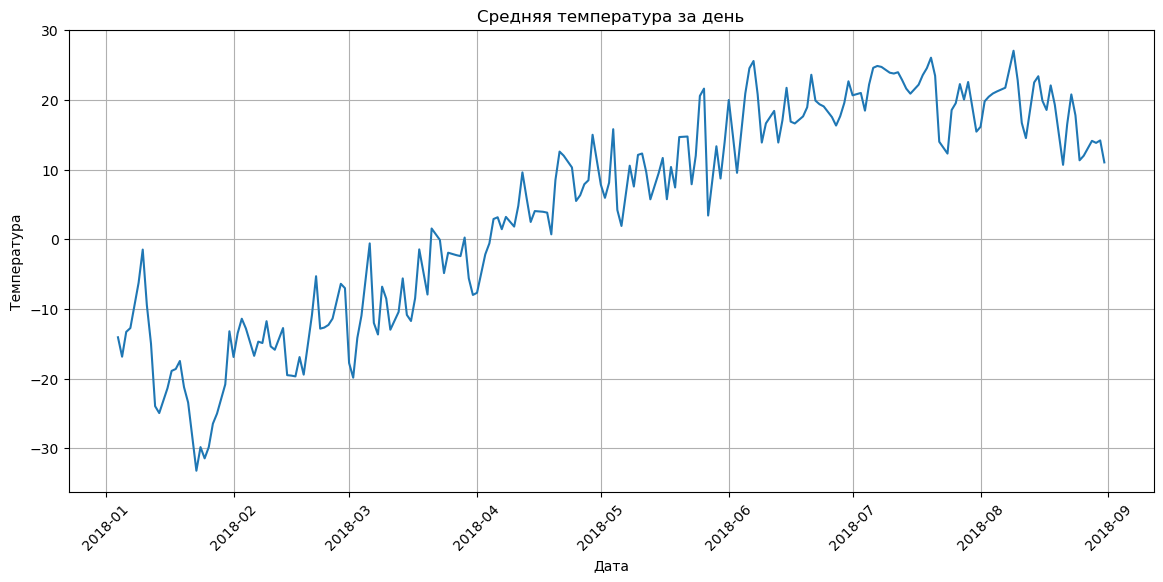

In [28]:
plt.figure(figsize=(14,6))
plt.plot(
    merged_df['Дата'],
    merged_df['T']
)
plt.title('Средняя температура за день')
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()